<a href="https://colab.research.google.com/github/amritpaxt/SkillMap_core_trinity/blob/main/scanning_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
from google.colab import files
uploaded = files.upload()

Saving resume_data_science.pdf to resume_data_science.pdf


In [39]:
!pip install PyPDF2

Select a job title from the list below:
1. Data Scientist
2. Machine Learning Engineer
3. Backend Developer
4. Frontend Developer
5. Full Stack Developer
6. Devops Engineer
7. Software Engineer
8. Cybersecurity Analyst
9. Data Analyst
10. Ai Engineer
Enter the number of your chosen job: 1

You selected: Data Scientist
Required Skills: ['python', 'machine learning', 'pandas', 'numpy', 'statistics', 'data visualization']

Resume File: resume_data_science.pdf
TF-IDF Similarity Score: 38.89%
Skill Match Score: 100.0%
🔥 Final Hybrid Match Score: 69.45%

Matched Skills: ['python', 'machine learning', 'pandas', 'numpy', 'statistics', 'data visualization']
Missing Skills: []


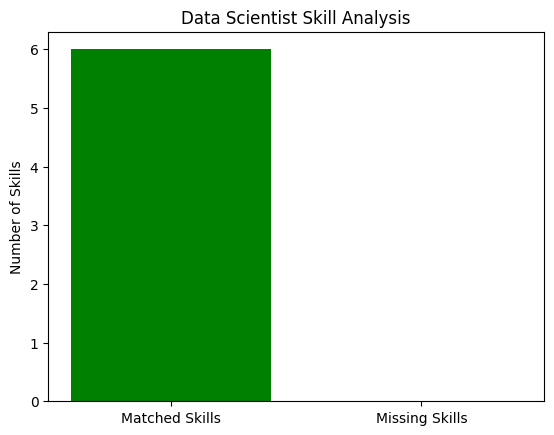

In [44]:


# 3️⃣ Import libraries
import PyPDF2
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 4️⃣ Predefined job titles and skills
job_skills_dict = {
    "data_scientist": ["python", "machine learning", "pandas", "numpy", "statistics", "data visualization"],
    "machine_learning_engineer": ["python", "machine learning", "tensorflow", "pytorch", "data preprocessing", "model evaluation"],
    "backend_developer": ["python", "django", "flask", "sql", "rest api", "git"],
    "frontend_developer": ["html", "css", "javascript", "react", "responsive design", "git"],
    "full_stack_developer": ["html", "css", "javascript", "react", "node.js", "sql", "git"],
    "devops_engineer": ["docker", "kubernetes", "aws", "linux", "ci/cd", "git"],
    "software_engineer": ["java", "python", "data structures", "algorithms", "git", "problem solving"],
    "cybersecurity_analyst": ["network security", "linux", "penetration testing", "cryptography", "security tools"],
    "data_analyst": ["sql", "python", "pandas", "data visualization", "excel", "statistics"],
    "ai_engineer": ["python", "machine learning", "deep learning", "tensorflow", "nlp", "data preprocessing"]
}

# 5️⃣ Extract text from PDF
def extract_text_from_pdf(file_path):
    text = ""
    with open(file_path, "rb") as file:
        reader = PyPDF2.PdfReader(file)
        for page in reader.pages:
            page_text = page.extract_text()
            if page_text:
                text += page_text + " "
    return text

# 6️⃣ Clean text
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# 7️⃣ Select uploaded resume
resume_file = list(uploaded.keys())[0]
resume_text = extract_text_from_pdf(resume_file)
resume_clean = clean_text(resume_text)

# 8️⃣ Show job titles and let user select one
print("Select a job title from the list below:")
for i, job in enumerate(job_skills_dict.keys()):
    print(f"{i+1}. {job.replace('_', ' ').title()}")

job_choice = int(input("Enter the number of your chosen job: "))
job_title = list(job_skills_dict.keys())[job_choice - 1]
required_skills = job_skills_dict[job_title]

print(f"\nYou selected: {job_title.replace('_',' ').title()}")
print("Required Skills:", required_skills)

# 9️⃣ Create job description text
job_description = " ".join(required_skills)
job_clean = clean_text(job_description)

# 1️⃣0️⃣ TF-IDF similarity
documents = [resume_clean, job_clean]
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(documents)
tfidf_similarity = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]

# 1️⃣1️⃣ Skill matching
matched_skills = [skill for skill in required_skills if skill.lower() in resume_clean]
missing_skills = [skill for skill in required_skills if skill.lower() not in resume_clean]
skill_match_percentage = len(matched_skills)/len(required_skills)

# 1️⃣2️⃣ Hybrid score
final_score = (tfidf_similarity*0.5 + skill_match_percentage*0.5) * 100

# 1️⃣3️⃣ Print results
print(f"\nResume File: {resume_file}")
print(f"TF-IDF Similarity Score: {round(tfidf_similarity*100,2)}%")
print(f"Skill Match Score: {round(skill_match_percentage*100,2)}%")
print(f"🔥 Final Hybrid Match Score: {round(final_score,2)}%\n")
print("Matched Skills:", matched_skills)
print("Missing Skills:", missing_skills)

# 1️⃣4️⃣ Graph
labels = ["Matched Skills","Missing Skills"]
values = [len(matched_skills), len(missing_skills)]

plt.bar(labels, values, color=['green','red'])
plt.title(f"{job_title.replace('_',' ').title()} Skill Analysis")
plt.ylabel("Number of Skills")
plt.show()